In [2]:
!pip install xgboost


     -------------------------------------- 150.0/150.0 MB 2.8 MB/s eta 0:00:00


In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn import metrics
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

In [6]:
#Latin-1 is used to correctly read special characters in the CSV that may cause errors with default UTF-8 encoding.
df = pd.read_csv('boxoffice.csv',encoding='latin-1')
df.head()

,title,domestic_revenue,world_revenue,distributor,opening_revenue,opening_theaters,budget,MPAA,genres,release_days
0,The Avengers,6026491,1274885664,Warner Bros.,163620146,253,174687337,R,Animation,16
1,Titanic,169411543,1132871091,Disney,85549990,122,103948486,G,Action,103
2,Jurassic Park,107836098,583329845,Sony,55681429,3826,122104991,NC-17,Horror,89
3,Avatar,51433697,1225323391,Disney,109775324,3868,46431596,G,Horror,85
4,The Lion King,142791649,604140729,Warner Bros.,59476800,2934,203513696,R,Comedy,158


In [8]:
df.shape

(2694, 10)

In [9]:
#This shows a summary of the DataFrame including column names, data types, and non-null counts.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2694 entries, 0 to 2693
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   title             2694 non-null   object
 1   domestic_revenue  2694 non-null   int64 
 2   world_revenue     2694 non-null   int64 
 3   distributor       2694 non-null   object
 4   opening_revenue   2694 non-null   int64 
 5   opening_theaters  2694 non-null   int64 
 6   budget            2694 non-null   int64 
 7   MPAA              2694 non-null   object
 8   genres            2694 non-null   object
 9   release_days      2694 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 210.6+ KB


In [10]:
#gives basic statistical details like mean, count, min, max, etc., for numeric columns.
df.describe()

,domestic_revenue,world_revenue,opening_revenue,opening_theaters,budget,release_days
count,2.694000e+03,2.694000e+03,2.694000e+03,2694.000000,2.694000e+03,2694.000000
mean,1.508539e+08,7.719177e+08,9.971321e+07,2263.039347,1.537996e+08,90.897550
std,8.579997e+07,4.284414e+08,5.721762e+07,1298.559140,8.557624e+07,50.894041
min,8.277650e+05,3.261301e+06,1.385690e+05,10.000000,5.197977e+06,1.000000
25%,7.673272e+07,3.991135e+08,5.033848e+07,1161.000000,7.861876e+07,47.000000
50%,1.525725e+08,7.665551e+08,9.981418e+07,2271.500000,1.562567e+08,91.000000
75%,2.247314e+08,1.143920e+09,1.489805e+08,3392.250000,2.274832e+08,135.000000
max,2.998107e+08,1.499310e+09,1.999336e+08,4499.000000,2.998597e+08,179.000000


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
domestic_revenue,2694.0,1.508539e+08,8.579997e+07,827765.0,7.673272e+07,152572473.5,2.247314e+08,2.998107e+08
world_revenue,2694.0,7.719177e+08,4.284414e+08,3261301.0,3.991135e+08,766555142.5,1.143920e+09,1.499310e+09
opening_revenue,2694.0,9.971321e+07,5.721762e+07,138569.0,5.033848e+07,99814175.0,1.489805e+08,1.999336e+08
opening_theaters,2694.0,2.263039e+03,1.298559e+03,10.0,1.161000e+03,2271.5,3.392250e+03,4.499000e+03
budget,2694.0,1.537996e+08,8.557624e+07,5197977.0,7.861876e+07,156256716.0,2.274832e+08,2.998597e+08
release_days,2694.0,9.089755e+01,5.089404e+01,1.0,4.700000e+01,91.0,1.350000e+02,1.790000e+02


In [13]:
# Remove 'world_revenue' and 'opening_revenue' columns from the DataFrame as we dont use them anywhere in this project 
to_remove = ['world_revenue', 'opening_revenue']
df.drop(to_remove, axis=1, inplace=True)

In [14]:
df.head()

,title,domestic_revenue,distributor,opening_theaters,budget,MPAA,genres,release_days
0,The Avengers,6026491,Warner Bros.,253,174687337,R,Animation,16
1,Titanic,169411543,Disney,122,103948486,G,Action,103
2,Jurassic Park,107836098,Sony,3826,122104991,NC-17,Horror,89
3,Avatar,51433697,Disney,3868,46431596,G,Horror,85
4,The Lion King,142791649,Warner Bros.,2934,203513696,R,Comedy,158


In [16]:
# Calculate the percentage of missing values in each column
df.isnull().sum() * 100 / df.shape[0]

title               0.0
domestic_revenue    0.0
distributor         0.0
opening_theaters    0.0
budget              0.0
MPAA                0.0
genres              0.0
release_days        0.0
dtype: float64

In [19]:
df.genres.isnull().sum()
df.MPAA.isnull().sum()

0

In [21]:
df.drop('budget', axis=1, inplace=True)

In [24]:
#Clean and convert columns to numeric by removing symbols/commas 
df['domestic_revenue'] = df['domestic_revenue'].astype(str).str[1:]

for col in ['domestic_revenue', 'opening_theaters', 'release_days']:
    df[col] = df[col].astype(str).str.replace(',', '') 
# Convert non-null values to float and coerce invalid entries to NaN for safe numeric conversion

    temp = (~df[col].isnull()) 
    df[temp][col] = df[temp][col].convert_dtypes(float) 

    df[col] = pd.to_numeric(df[col], errors='coerce')


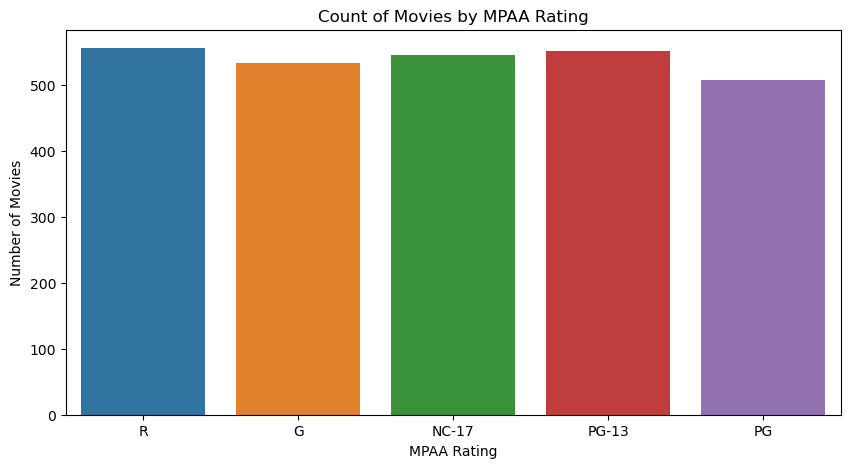

In [26]:
#now here we are looking how many movies fall under each MPAA
plt.figure(figsize=(10, 5))
sb.countplot(x='MPAA', data=df)
plt.title("Count of Movies by MPAA Rating")
plt.xlabel("MPAA Rating")
plt.ylabel("Number of Movies")
plt.show()

In [28]:
#now we will group by each MPAA category and calculate mean foe domestic revenue 
df.groupby('MPAA')['domestic_revenue'].mean()
#here PG and R have higher values 
#PG = Parental Guidance suggested
#R = Restricted (under 17 needs an adult)

MPAA
G        3.320203e+06
NC-17    3.095755e+06
PG       3.388151e+06
PG-13    3.070569e+06
R        3.353680e+06
Name: domestic_revenue, dtype: float64

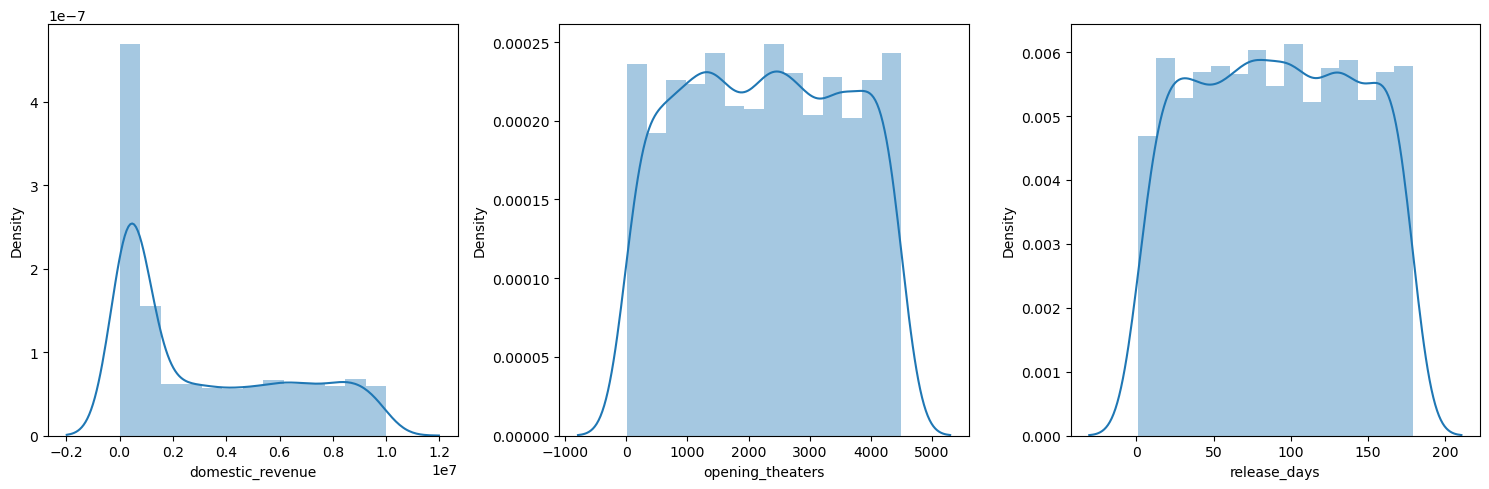

In [29]:
## Show the distribution (spread) of selected columns using plot
plt.subplots(figsize=(15, 5))
features = ['domestic_revenue', 'opening_theaters', 'release_days']
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sb.distplot(df[col])
plt.tight_layout()
plt.show()

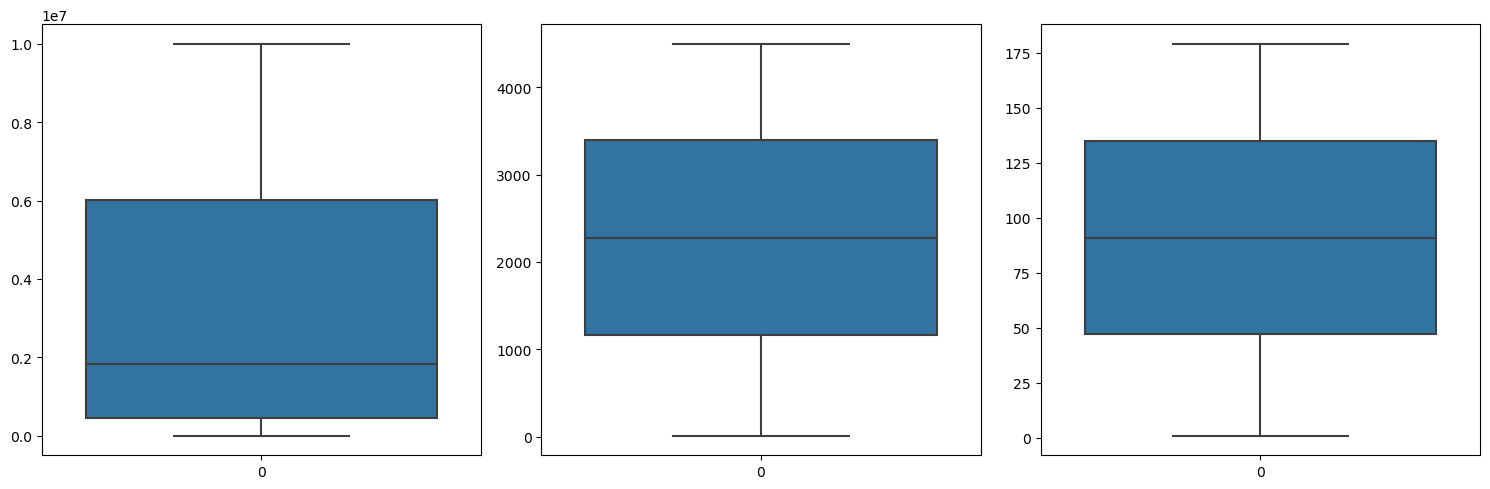

In [30]:
plt.subplots(figsize=(15, 5))
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sb.boxplot(df[col])
plt.tight_layout()
plt.show()

In [31]:
for col in features:
    df[col] = df[col].apply(lambda x: np.log10(x))

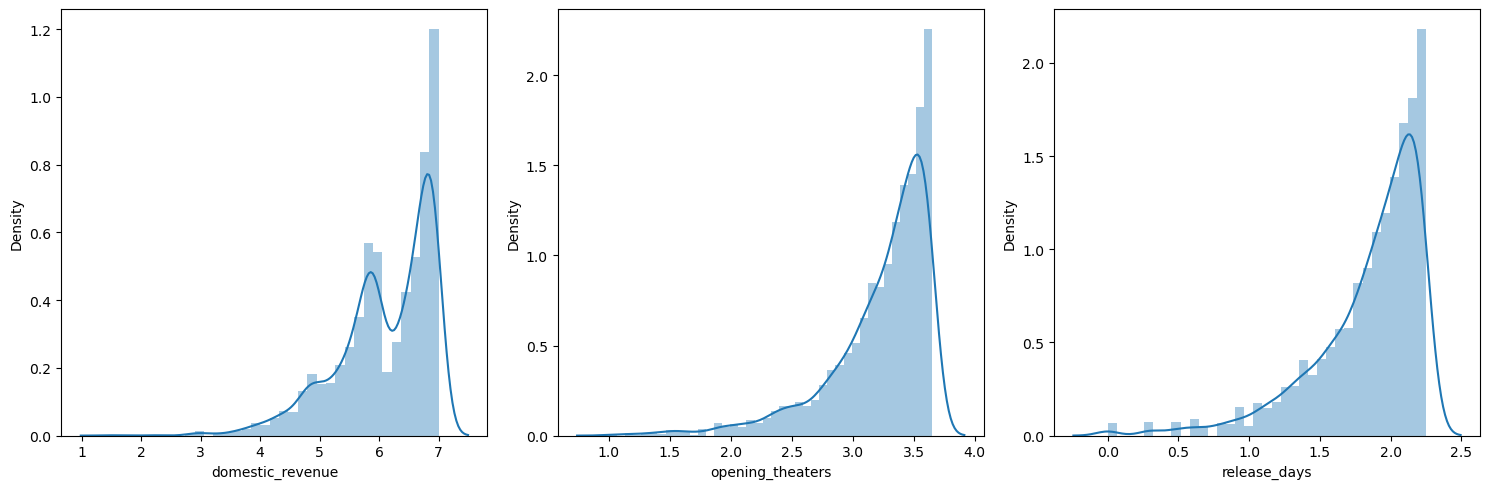

In [32]:
plt.subplots(figsize=(15, 5))
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sb.distplot(df[col])
plt.tight_layout()
plt.show()

In [33]:
vectorizer = CountVectorizer() 
vectorizer.fit(df['genres']) 
features = vectorizer.transform(df['genres']).toarray() 

genres = vectorizer.get_feature_names_out() 
for i, name in enumerate(genres): 
	df[name] = features[:, i] 

df.drop('genres', axis=1, inplace=True)

In [34]:
removed = 0

if 'action' in df.columns and 'western' in df.columns:
    for col in df.loc[:, 'action':'western'].columns: 
        
        if (df[col] == 0).mean() > 0.95: 
            removed += 1
            df.drop(col, axis=1, inplace=True) 

print(removed) 
print(df.shape)

0
(2694, 12)


In [35]:
df.head()

,title,domestic_revenue,distributor,opening_theaters,MPAA,release_days,action,animation,comedy,drama,horror,thriller
0,The Avengers,3.812312,Warner Bros.,2.403121,R,1.204120,0,1,0,0,0,0
1,Titanic,6.973661,Disney,2.086360,G,2.012837,1,0,0,0,0,0
2,Jurassic Park,5.922257,Sony,3.582745,NC-17,1.949390,0,0,0,0,1,0
3,Avatar,5.637186,Disney,3.587486,G,1.929419,0,0,0,0,1,0
4,The Lion King,6.445861,Warner Bros.,3.467460,R,2.198657,0,0,1,0,0,0


In [36]:
for col in ['distributor', 'MPAA']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

,title,domestic_revenue,distributor,opening_theaters,MPAA,release_days,action,animation,comedy,drama,horror,thriller
0,The Avengers,3.812312,4,2.403121,4,1.204120,0,1,0,0,0,0
1,Titanic,6.973661,0,2.086360,0,2.012837,1,0,0,0,0,0
2,Jurassic Park,5.922257,2,3.582745,1,1.949390,0,0,0,0,1,0
3,Avatar,5.637186,0,3.587486,0,1.929419,0,0,0,0,1,0
4,The Lion King,6.445861,4,3.467460,4,2.198657,0,0,1,0,0,0


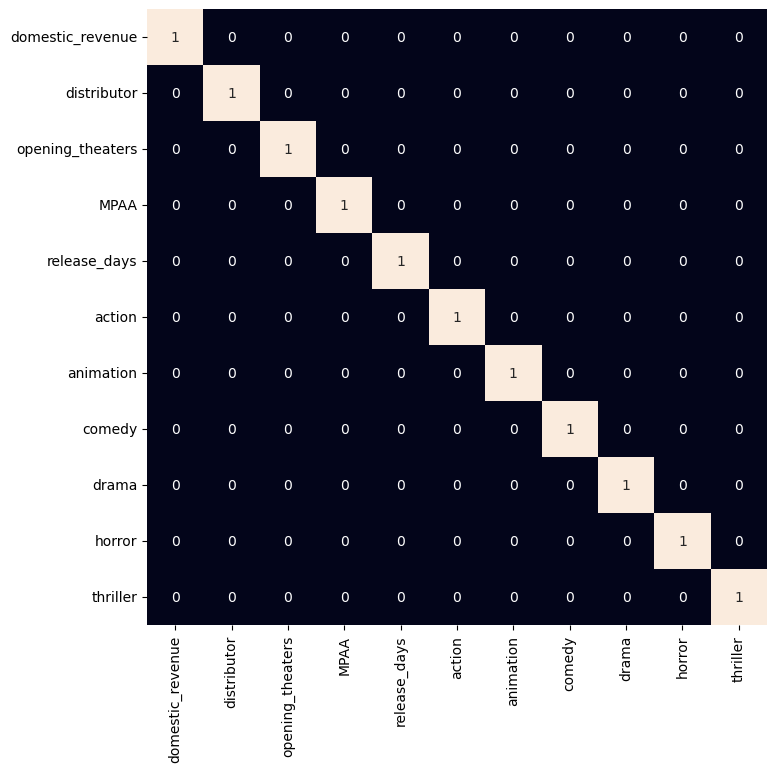

In [38]:
plt.figure(figsize=(8, 8))
sb.heatmap(df.select_dtypes(include=np.number).corr() > 0.8, 
            annot=True, 
            cbar=False) 
plt.show()

In [39]:
features = df.drop(['title', 'domestic_revenue'], axis=1) 
target = df['domestic_revenue'].values 

X_train, X_val, Y_train, Y_val = train_test_split(features, target, 
									test_size=0.1, 
									random_state=22) 
X_train.shape, X_val.shape

((2424, 10), (270, 10))

In [40]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [41]:
from sklearn.metrics import mean_absolute_error as mae
model = XGBRegressor()
model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [42]:
train_preds = model.predict(X_train) 
print('Training Error : ', mae(Y_train, train_preds)) 

val_preds = model.predict(X_val) 
print('Validation Error : ', mae(Y_val, val_preds)) 
print()

Training Error :  0.23834028038319702
Validation Error :  0.7129402518337751



In [43]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_train = np.sqrt(mean_squared_error(Y_train, train_preds))
rmse_val = np.sqrt(mean_squared_error(Y_val, val_preds))

print("Training RMSE :", rmse_train)
print("Validation RMSE :", rmse_val)


Training RMSE : 0.3175410531995367
Validation RMSE : 0.8812946925753562


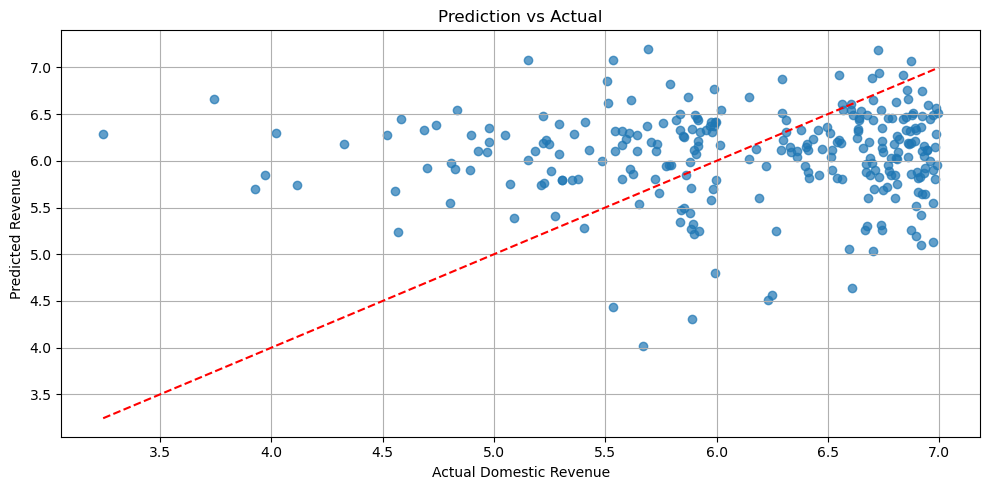

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.scatter(Y_val, val_preds, alpha=0.7)
plt.plot([Y_val.min(), Y_val.max()], [Y_val.min(), Y_val.max()], 'r--')
plt.xlabel("Actual Domestic Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Prediction vs Actual")
plt.grid(True)
plt.tight_layout()
plt.show()